In [5]:
!pip install imbalanced-learn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [7]:
df = pd.read_csv("/content/credit_card_fraud_10k.csv")

In [8]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [9]:
df.shape

(10000, 10)

In [10]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [12]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [13]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["is_fraud"].value_counts()

,count
is_fraud,
0,9849
1,151


In [16]:
df["is_fraud"].value_counts(normalize=True) * 100

,proportion
is_fraud,
0,98.49
1,1.51


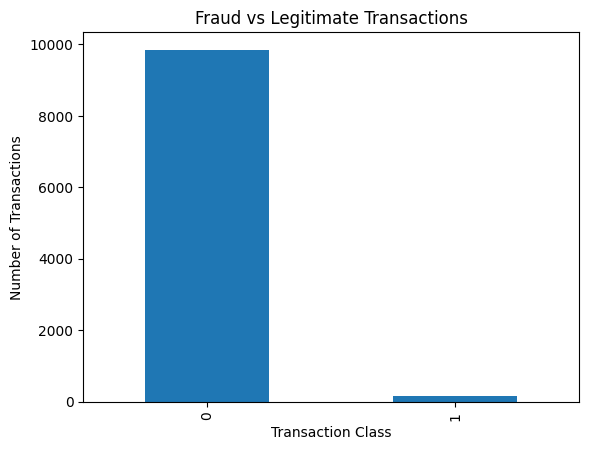

In [17]:
df["is_fraud"].value_counts().plot(kind="bar")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.show()

In [18]:
df["merchant_category"].value_counts()

,count
merchant_category,
Food,2093
Clothing,2050
Travel,1990
Grocery,1944
Electronics,1923


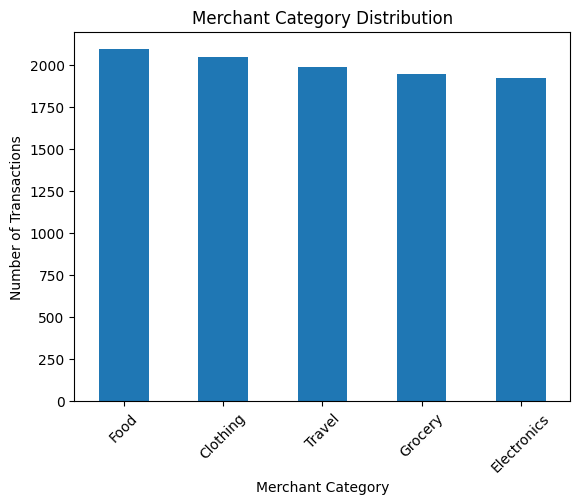

In [19]:
df["merchant_category"].value_counts().plot(kind="bar")

plt.title("Merchant Category Distribution")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

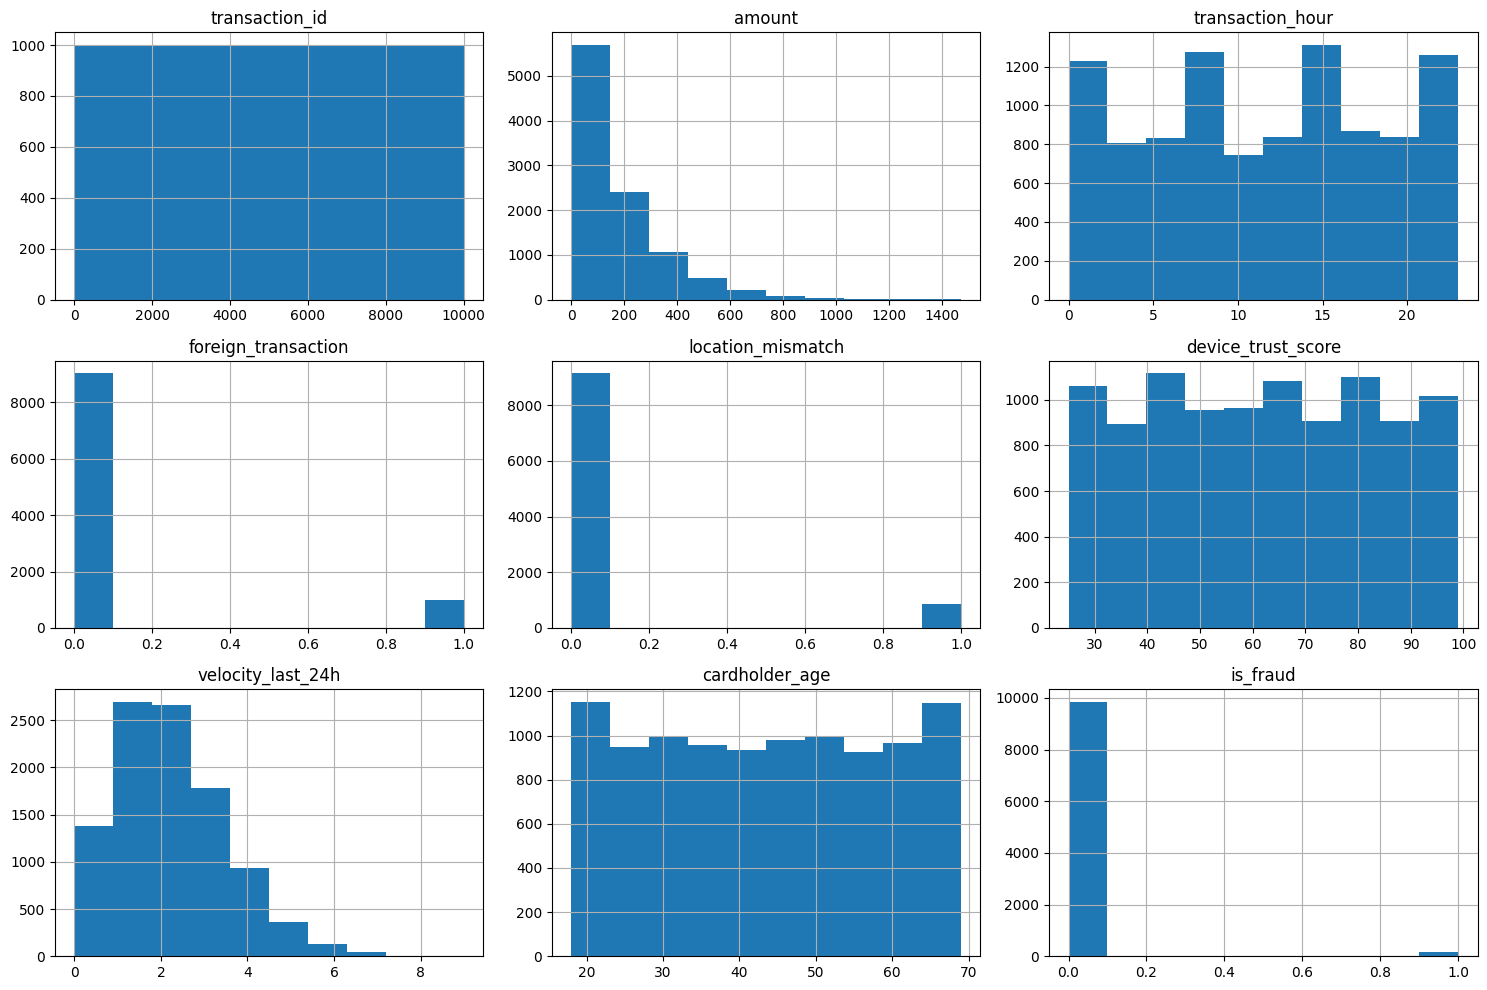

In [20]:
df.hist(figsize=(15, 10))

plt.tight_layout()
plt.show()

In [21]:
pd.crosstab(
    df["foreign_transaction"],
    df["is_fraud"],
    normalize="index"
) * 100

is_fraud,0,1
foreign_transaction,,
0,99.235203,0.764797
1,91.615542,8.384458


In [22]:
pd.crosstab(
    df["location_mismatch"],
    df["is_fraud"],
    normalize="index"
) * 100

is_fraud,0,1
location_mismatch,,
0,99.135951,0.864049
1,91.598600,8.401400


In [23]:
df.groupby("is_fraud")["device_trust_score"].mean()

,device_trust_score
is_fraud,
0,62.165804
1,37.867550


In [24]:
df.groupby("is_fraud")["velocity_last_24h"].mean()

,velocity_last_24h
is_fraud,
0,1.990557
1,3.205298


In [25]:
df.groupby("is_fraud")["amount"].mean()

,amount
is_fraud,
0,175.333015
1,216.182980


In [26]:
df.groupby("is_fraud")["transaction_hour"].mean()

,transaction_hour
is_fraud,
0,11.712154
1,3.841060


In [27]:
X = df.drop(columns=["is_fraud", "transaction_id"])
y = df["is_fraud"]

In [28]:
X.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
0,84.47,22,Electronics,0,0,66,3,40
1,541.82,3,Travel,1,0,87,1,64
2,237.01,17,Grocery,0,0,49,1,61
3,164.33,4,Grocery,0,1,72,3,34
4,30.53,15,Food,0,0,79,0,44


In [29]:
y.head()

,is_fraud
0,0
1,0
2,0
3,0
4,0


In [30]:
numeric_features = [
    "amount",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age"
]

categorical_features = [
    "merchant_category"
]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
print("Training set:")
print(y_train.value_counts())

print("\nTest set:")
print(y_test.value_counts())

Training set:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Test set:
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [34]:
logistic_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [35]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'transaction_hour',
                                                   'foreign_transaction',
                                                   'location_mismatch',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['merchant_category'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [36]:
y_pred_lr = logistic_pipeline.predict(X_test)

In [37]:
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

In [38]:
precision_lr = precision_score(y_test, y_pred_lr)
print("Logistic Regression Precision:", precision_lr)

Logistic Regression Precision: 0.2871287128712871


In [39]:
recall_lr = recall_score(y_test, y_pred_lr)
print("Logistic Regression Recall:", recall_lr)

Logistic Regression Recall: 0.9666666666666667


In [40]:
f1_lr = f1_score(y_test, y_pred_lr)
print("Logistic Regression F1:", f1_lr)

Logistic Regression F1: 0.44274809160305345


In [41]:
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
print("Logistic Regression ROC-AUC:", roc_auc_lr)

Logistic Regression ROC-AUC: 0.9932994923857867


In [42]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.29      0.97      0.44        30

    accuracy                           0.96      2000
   macro avg       0.64      0.97      0.71      2000
weighted avg       0.99      0.96      0.97      2000



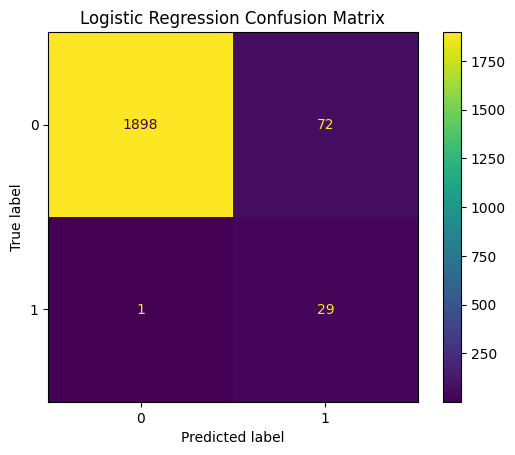

In [83]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.savefig("/content/images/confusion_matrix_lr.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()

In [44]:
rf_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [45]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'transaction_hour',
                                                   'foreign_transaction',
                                                   'location_mismatch',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['merchant_category'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [46]:
y_pred_rf = rf_pipeline.predict(X_test)

In [47]:
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [48]:
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

In [49]:
print("Random Forest Precision:", precision_rf)
print("Random Forest Recall:", recall_rf)
print("Random Forest F1:", f1_rf)
print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest Precision: 1.0
Random Forest Recall: 0.6333333333333333
Random Forest F1: 0.7755102040816326
Random Forest ROC-AUC: 0.9992554991539763


In [50]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.63      0.78        30

    accuracy                           0.99      2000
   macro avg       1.00      0.82      0.89      2000
weighted avg       0.99      0.99      0.99      2000



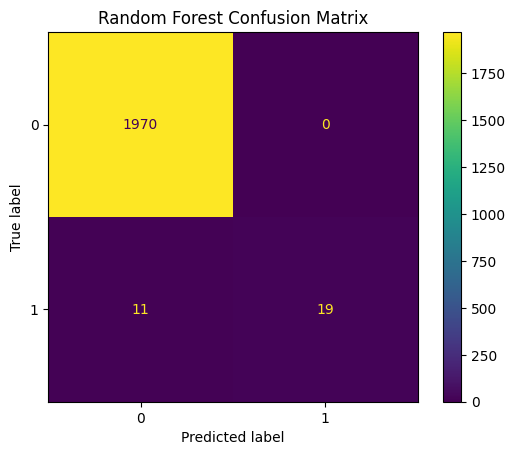

In [86]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.savefig("/content/images/confusion_matrix_rf.png", bbox_inches="tight", dpi=300)
plt.show()

In [52]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_lr,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_rf
    ],
    "F1-Score": [
        f1_lr,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf
    ]
})

results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.287129,0.966667,0.442748,0.993299
1,Random Forest,1.000000,0.633333,0.775510,0.999255


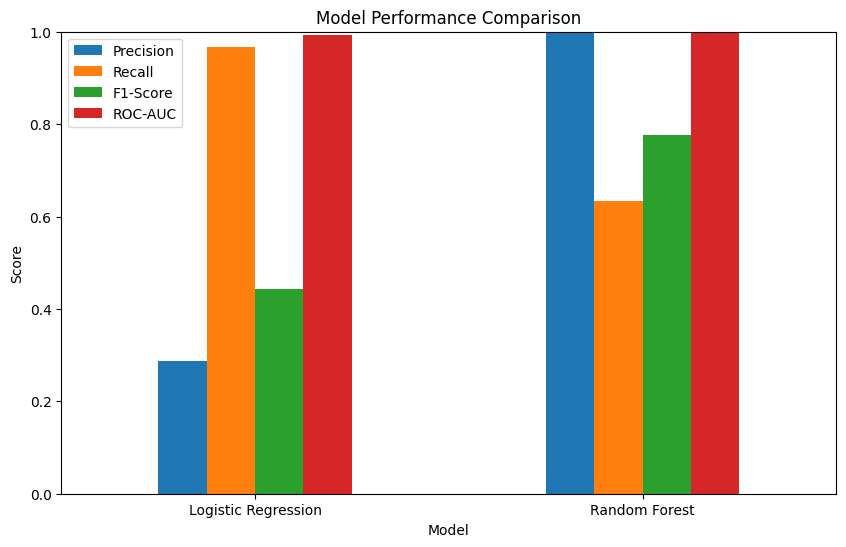

In [84]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.savefig("/content/images/model_comparison.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()

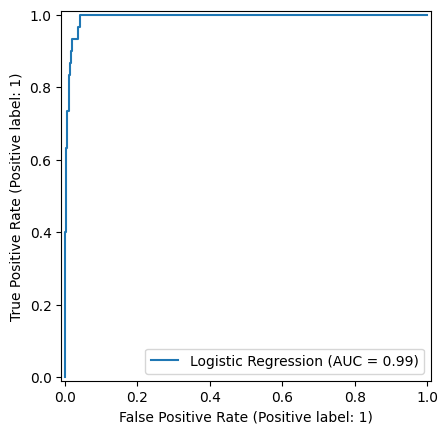

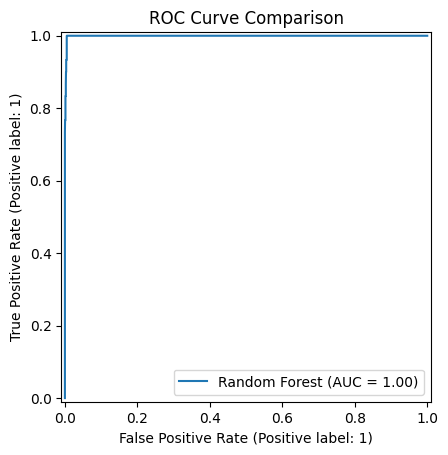

In [85]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.savefig("/content/images/roc_curve.png", bbox_inches="tight", dpi=300)
plt.show()

In [55]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

In [56]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [57]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['amount',
                                                                          'transaction_hour',
                                                                          'foreign_transaction',
                                                                          'location_mismatch',
                                                                          'device_trust_score',
                                                                          'velocity_last_24h',
                                                                          'cardholder_age']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['merchant_category'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        RandomForestClassifier(n_estimators=200,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=1)

In [58]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}


In [59]:
print("Best CV ROC-AUC:")
print(grid_search.best_score_)

Best CV ROC-AUC:
0.9978860764644267


In [60]:
best_rf = grid_search.best_estimator_

In [61]:
y_pred_tuned = best_rf.predict(X_test)

In [62]:
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

In [63]:
precision_tuned = precision_score(
    y_test,
    y_pred_tuned
)

recall_tuned = recall_score(
    y_test,
    y_pred_tuned
)

f1_tuned = f1_score(
    y_test,
    y_pred_tuned
)

roc_auc_tuned = roc_auc_score(
    y_test,
    y_prob_tuned
)

In [64]:
print("Tuned Random Forest")
print("-------------------")
print("Precision:", precision_tuned)
print("Recall:", recall_tuned)
print("F1-Score:", f1_tuned)
print("ROC-AUC:", roc_auc_tuned)

Tuned Random Forest
-------------------
Precision: 1.0
Recall: 0.6333333333333333
F1-Score: 0.7755102040816326
ROC-AUC: 0.9992047377326565


In [65]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Precision": [
        precision_lr,
        precision_rf,
        precision_tuned
    ],
    "Recall": [
        recall_lr,
        recall_rf,
        recall_tuned
    ],
    "F1-Score": [
        f1_lr,
        f1_rf,
        f1_tuned
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_tuned
    ]
})

final_results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.287129,0.966667,0.442748,0.993299
1,Random Forest,1.000000,0.633333,0.775510,0.999255
2,Tuned Random Forest,1.000000,0.633333,0.775510,0.999205


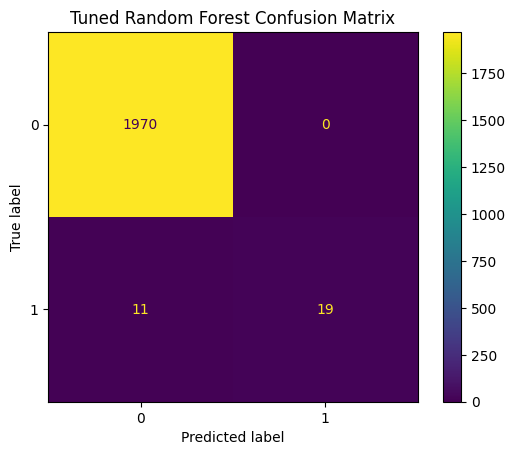

In [66]:
cm_final = confusion_matrix(
    y_test,
    y_pred_tuned
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final
)

disp.plot()

plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [67]:
preprocessor_fitted = best_rf.named_steps["preprocessor"]

In [68]:
feature_names = preprocessor_fitted.get_feature_names_out()

In [69]:
importances = best_rf.named_steps["classifier"].feature_importances_

In [70]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [71]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [72]:
feature_importance.head(15)

,Feature,Importance
1,num__transaction_hour,0.265054
4,num__device_trust_score,0.214686
2,num__foreign_transaction,0.139322
5,num__velocity_last_24h,0.130624
3,num__location_mismatch,0.123894
0,num__amount,0.024513
8,cat__merchant_category_Electronics,0.023660
10,cat__merchant_category_Grocery,0.017831
6,num__cardholder_age,0.016329
11,cat__merchant_category_Travel,0.015955


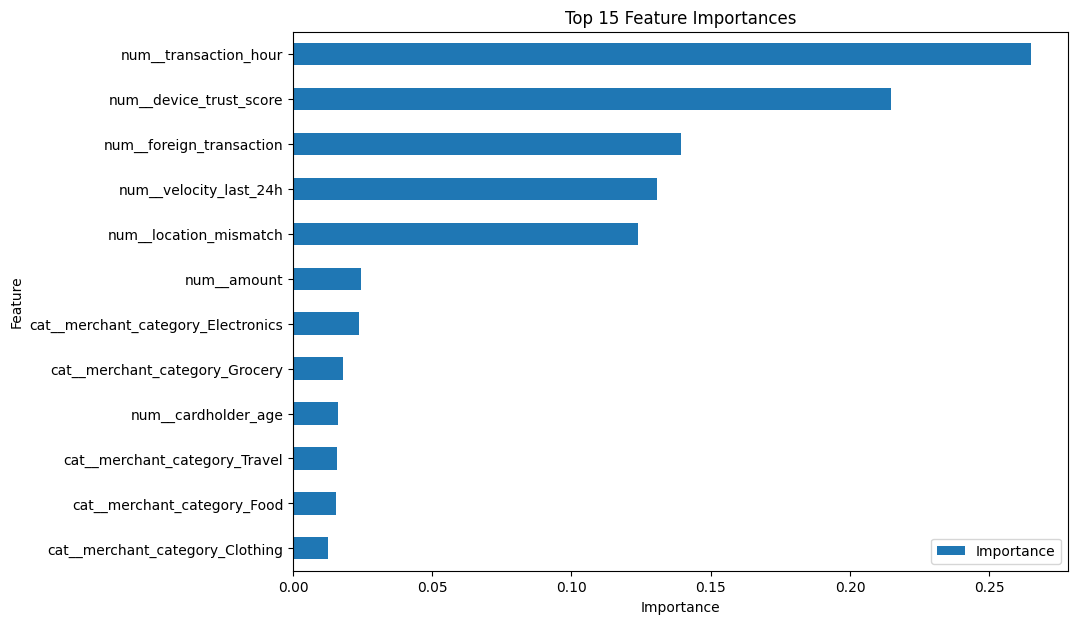

In [73]:
feature_importance.head(15).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [88]:
import os

os.makedirs("/content/images", exist_ok=True)
os.makedirs("/content/results", exist_ok=True)

print("Images folder:", os.path.exists("/content/images"))
print("Results folder:", os.path.exists("/content/results"))

Images folder: True
Results folder: True


In [89]:
final_results.to_csv(
    "/content/results/model_results.csv",
    index=False
)